In [2]:
import pandas as pd

rfm = pd.read_csv("../DataSet/customer_rfm.csv.csv")
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12362,NaN,1,130.00
1,12533,NaN,1,929.92
2,12615,NaN,1,-5.95
3,12636,NaN,1,141.00
4,12682,NaN,1,426.30


In [3]:
rfm.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary'], dtype='object')

In [4]:
def segment_customer(recency):
    if recency <= 30:
        return "Champions"
    elif recency <= 90:
        return "At Risk"
    else:
        return "Lost"

rfm["Segment"] = rfm["Recency"].apply(segment_customer)

In [5]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Segment
0,12362,NaN,1,130.00,Lost
1,12533,NaN,1,929.92,Lost
2,12615,NaN,1,-5.95,Lost
3,12636,NaN,1,141.00,Lost
4,12682,NaN,1,426.30,Lost


In [6]:
rfm["Segment"].value_counts()

Segment
Lost    49
Name: count, dtype: int64

In [7]:
segment_profile = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()

segment_profile

,Recency,Frequency,Monetary
Segment,,,
Lost,NaN,1.122449,437.986327


In [8]:
segment_profile.round(2)

,Recency,Frequency,Monetary
Segment,,,
Lost,NaN,1.12,437.99


In [9]:
segment_profile.to_csv("segment_profile.csv")

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

ValueError: No objects to concatenate

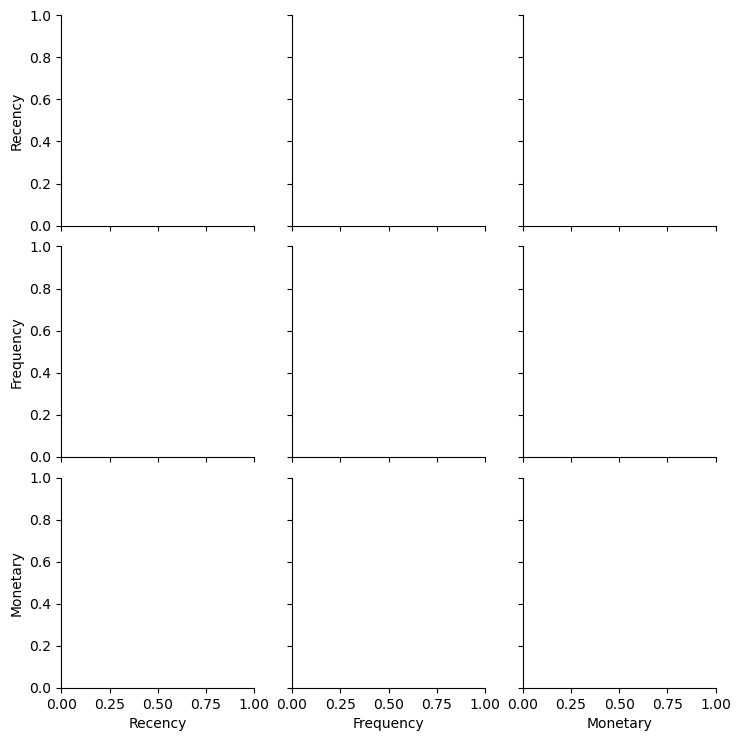

In [12]:
sns.pairplot(
    rfm,
    vars=["Recency", "Frequency", "Monetary"],
    hue="Segment",
    diag_kind="hist"
)

plt.show()

In [13]:
rfm["Segment"].value_counts()

Segment
Lost    49
Name: count, dtype: int64

In [14]:
rfm["Segment"] = pd.qcut(
    rfm["Recency"],
    q=3,
    labels=["Champions", "At Risk", "Lost"]
)

ValueError: Bin edges must be unique: Index([nan, nan, nan, nan], dtype='float64', name='Recency').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [15]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  49 non-null     int64  
 1   Recency     0 non-null      float64
 2   Frequency   49 non-null     int64  
 3   Monetary    49 non-null     float64
 4   Segment     49 non-null     object 
dtypes: float64(2), int64(2), object(1)
memory usage: 2.0+ KB


In [16]:
rfm["Recency"].head(10)

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: Recency, dtype: float64

In [17]:
rfm["Recency"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Recency, dtype: float64

In [18]:
import pandas as pd

df = pd.read_csv("cleaned_retail.csv")
print(df.shape)

(407650, 8)


In [19]:
df.shape
# (407650, 8)

(407650, 8)

In [20]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


In [21]:
print(df.head())

   Invoice StockCode                          Description  Quantity  \
0   489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1   489434    79323P                   PINK CHERRY LIGHTS        12   
2   489434    79323W                  WHITE CHERRY LIGHTS        12   
3   489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4   489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [22]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [23]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Price": lambda x: (x * df.loc[x.index, "Quantity"]).sum()
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

In [24]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [25]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2048.238233
std,1701.200176,96.860633,8.170213,8914.481278
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.987500
50%,15350.500000,53.000000,2.000000,706.020000
75%,16834.250000,136.000000,5.000000,1723.142500
max,18287.000000,374.000000,205.000000,349164.350000


In [26]:
rfm["Segment"] = pd.qcut(
    rfm["Recency"],
    q=3,
    labels=["Champions", "At Risk", "Lost"]
)

In [27]:
rfm["Segment"].value_counts()

Segment
Champions    1462
Lost         1435
At Risk      1415
Name: count, dtype: int64

In [29]:
segment_profile = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()

segment_profile

C:\Users\Admin\AppData\Local\Temp\ipykernel_4008\547071759.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_profile = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()


,Recency,Frequency,Monetary
Segment,,,
Champions,12.667579,7.799590,3924.809617
At Risk,53.916608,3.421201,1419.743922
Lost,207.889199,2.068990,756.093345


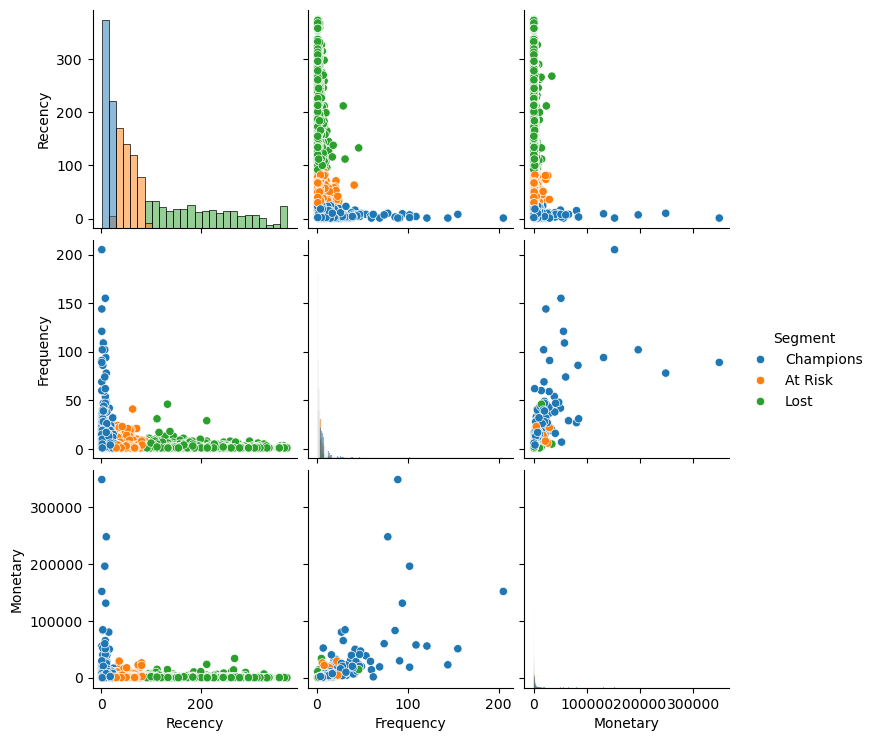

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    rfm,
    vars=["Recency", "Frequency", "Monetary"],
    hue="Segment",
    diag_kind="hist"
)

plt.show()

In [30]:
rfm.to_csv("customer_rfm_segmented.csv", index=False)

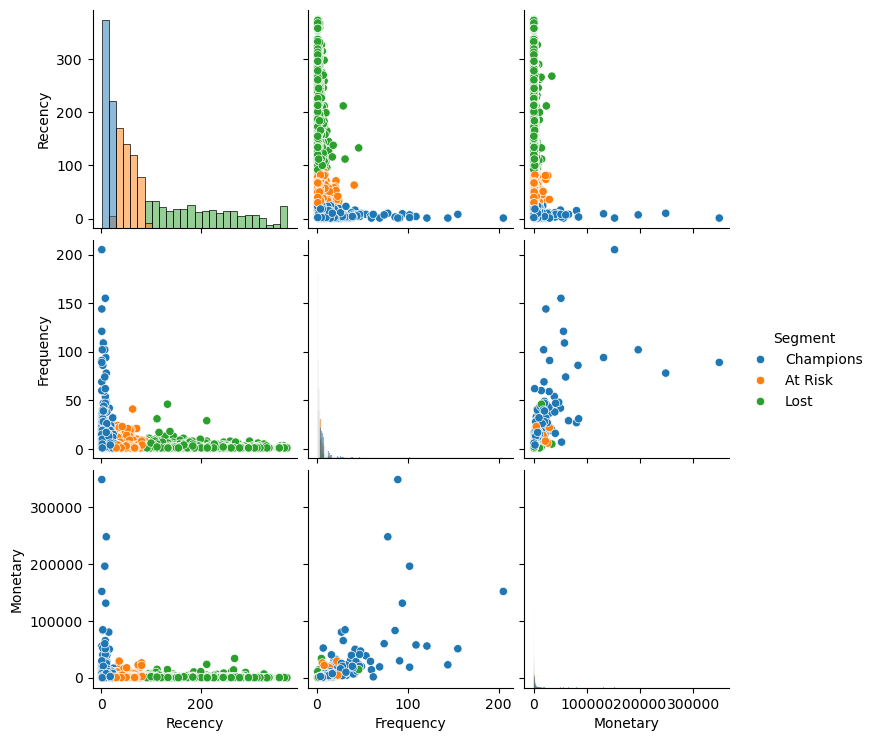

In [31]:
import matplotlib.pyplot as plt

g = sns.pairplot(
    rfm,
    vars=["Recency", "Frequency", "Monetary"],
    hue="Segment",
    diag_kind="hist"
)

g.savefig("customer_segment_pairplot.png", dpi=300)
plt.show()